# Toy Example of S-phase Copy Number Replication Normalization

May 24, 2024

## Goal:
Create a procedure to make clear the copy number correction process

## Inputs:
- Raw gene expression reads
- Replication timing profile (deconvolved time, more granular than the experiment)
- H matrix with information on how much of each cell has progressed through the cell cycle.



In [200]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [296]:
from src.ToyReplication import ToyReplication

# Let's create a replication profile with the dimensions of H
from src.delta_config import load_yl_delta_config
from src.helpers import calcH

length_timecourse = 160
step_min = 10 # Progress time by 10 minutes

# Experimental timepoints for the observed data later on
tps = np.arange(0, length_timecourse, step_min)

In [297]:
from src.config import load_configs_by_config_type
from src.global_config import GlobalConstants

config, _ = load_configs_by_config_type('shared')

# Create a replication profile from an H, mixture of S
# Decide on which deconvolved timepoints replication will occur for the 
# three positions in the genome

# Early, Mid, Late
experimental_times = tps
replication_indices = [100, 110, 120]

# Then for each position, we can compute a proportion of the population that has replicated
# from H
H, _ = config.calcH_function(config.intervals_wt1, GlobalConstants.CHROM_WT1_TIMEPOINTS)

In [298]:

n = len(replication_indices)
repl = np.ones((n, *H.shape))
mixture = repl.copy()

for i in range(n):
    repl_ind = replication_indices[i]
    repl[i, :, repl_ind:-1] *= 2
    mixture[i] = H * repl[i]

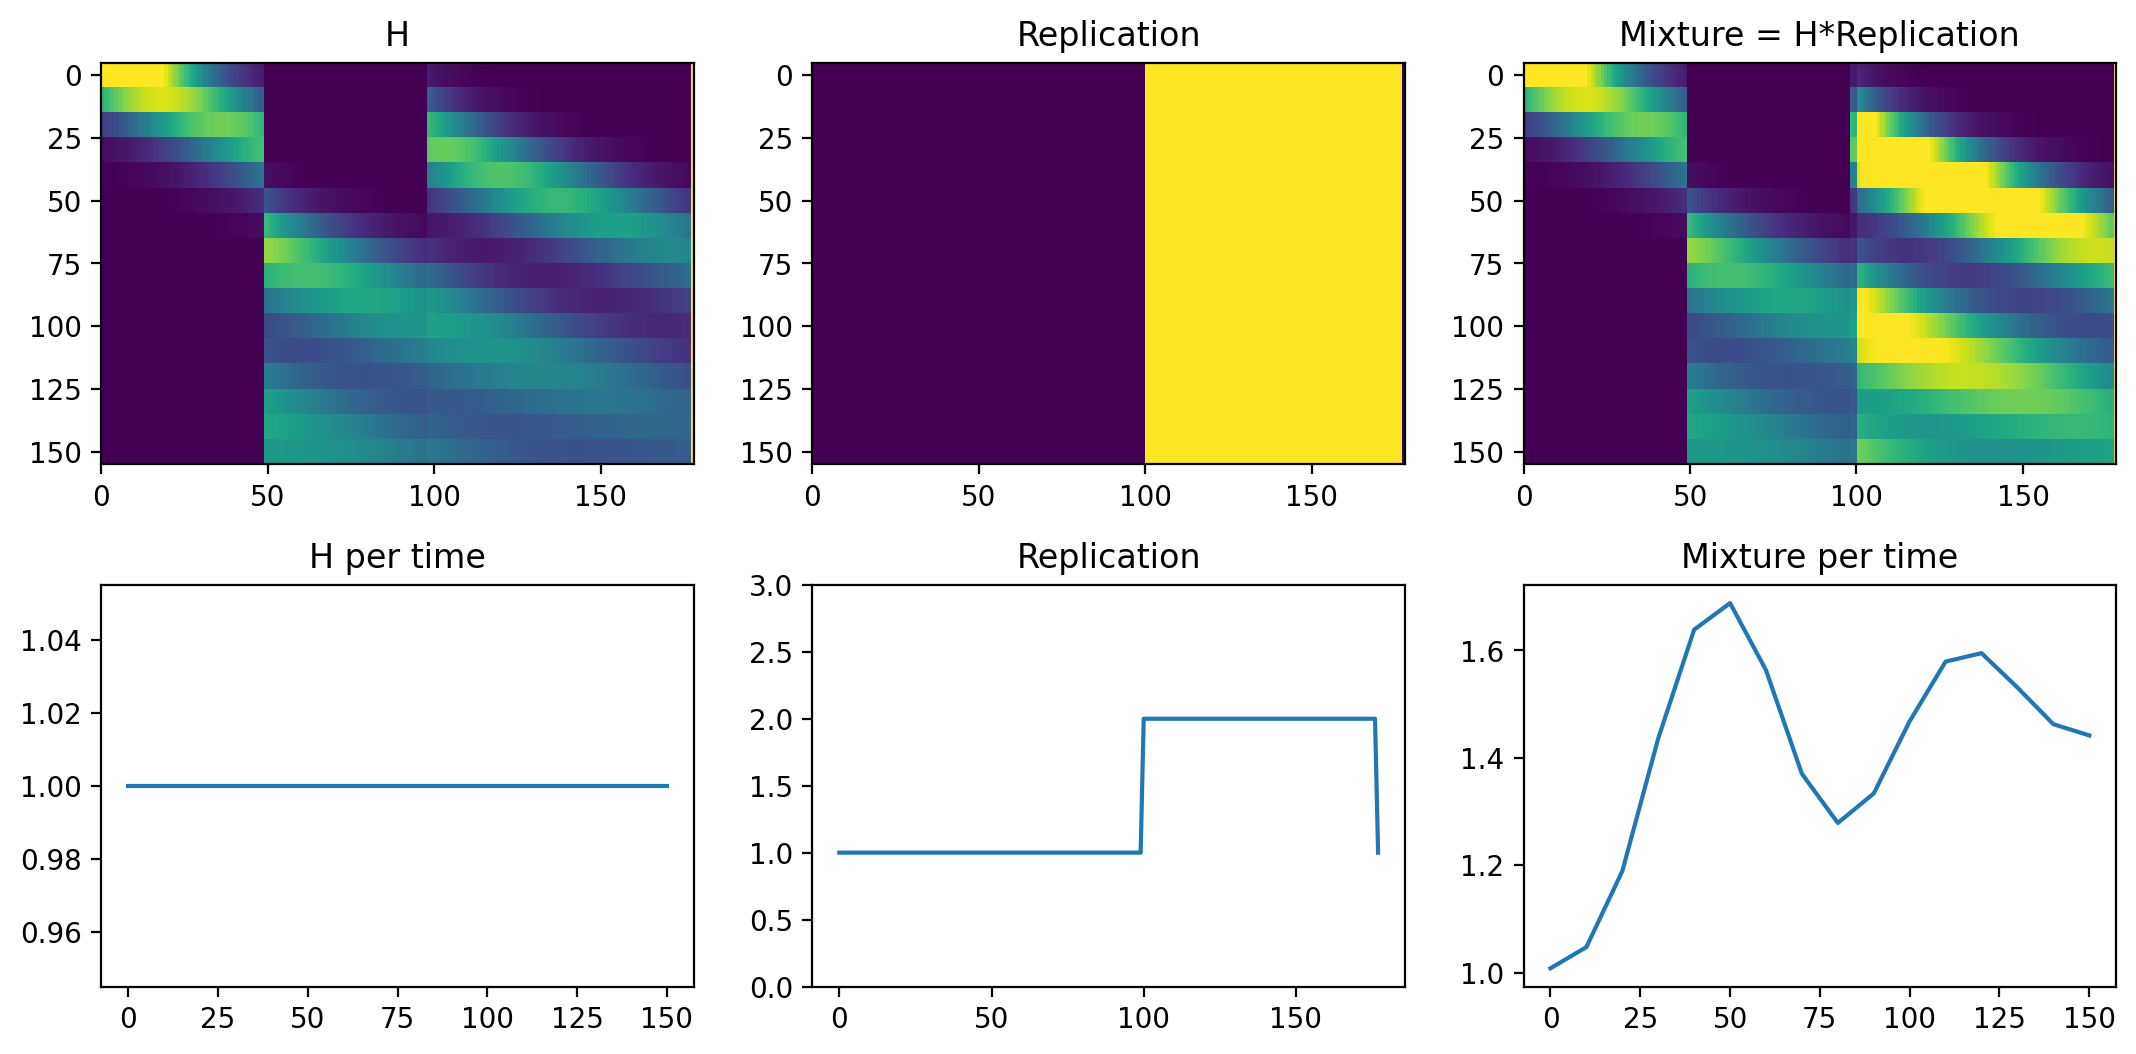

In [299]:

def plot_im(H, vmax):
    extent =[0, H.shape[1], -step_min/2, tps[-1]+step_min/2]
    plt.imshow(H, vmax=vmax, aspect='auto', extent=extent, origin='lower')
    plt.ylim(extent[-1], extent[-2])

i = 0
    
plt.figure(figsize=(13, 6))
plt.subplot(2, 3, 1)
plot_im(H, 0.02)
plt.title("H")

plt.subplot(2, 3, 2)
plot_im(repl[i], vmax=2)
plt.title("Replication")

plt.subplot(2, 3, 3)
plot_im(mixture[i], 0.02)
plt.title("Mixture = H*Replication")

plt.subplot(2, 3, 4)
plt.plot(tps, H.sum(axis=1))
plt.title("H per time")

plt.subplot(2, 3, 5)
plt.plot(repl[i, 0])
plt.title("Replication")
plt.ylim(0, 3)

plt.subplot(2, 3, 6)
plt.plot(tps, mixture[i].sum(axis=1))
plt.title("Mixture per time")

plt.subplots_adjust(hspace=0.3)

In [300]:
from src.copy_correction_reanalysis import CopyCorrectionAnalysis

copy_analysis = CopyCorrectionAnalysis()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:19.610
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:25.739


In [301]:
copy_analysis.compute_gene_10k_counts(1)

In [736]:
copy_analysis.scale_occupancy_curves()

In [747]:
copy_analysis.perform_correction()

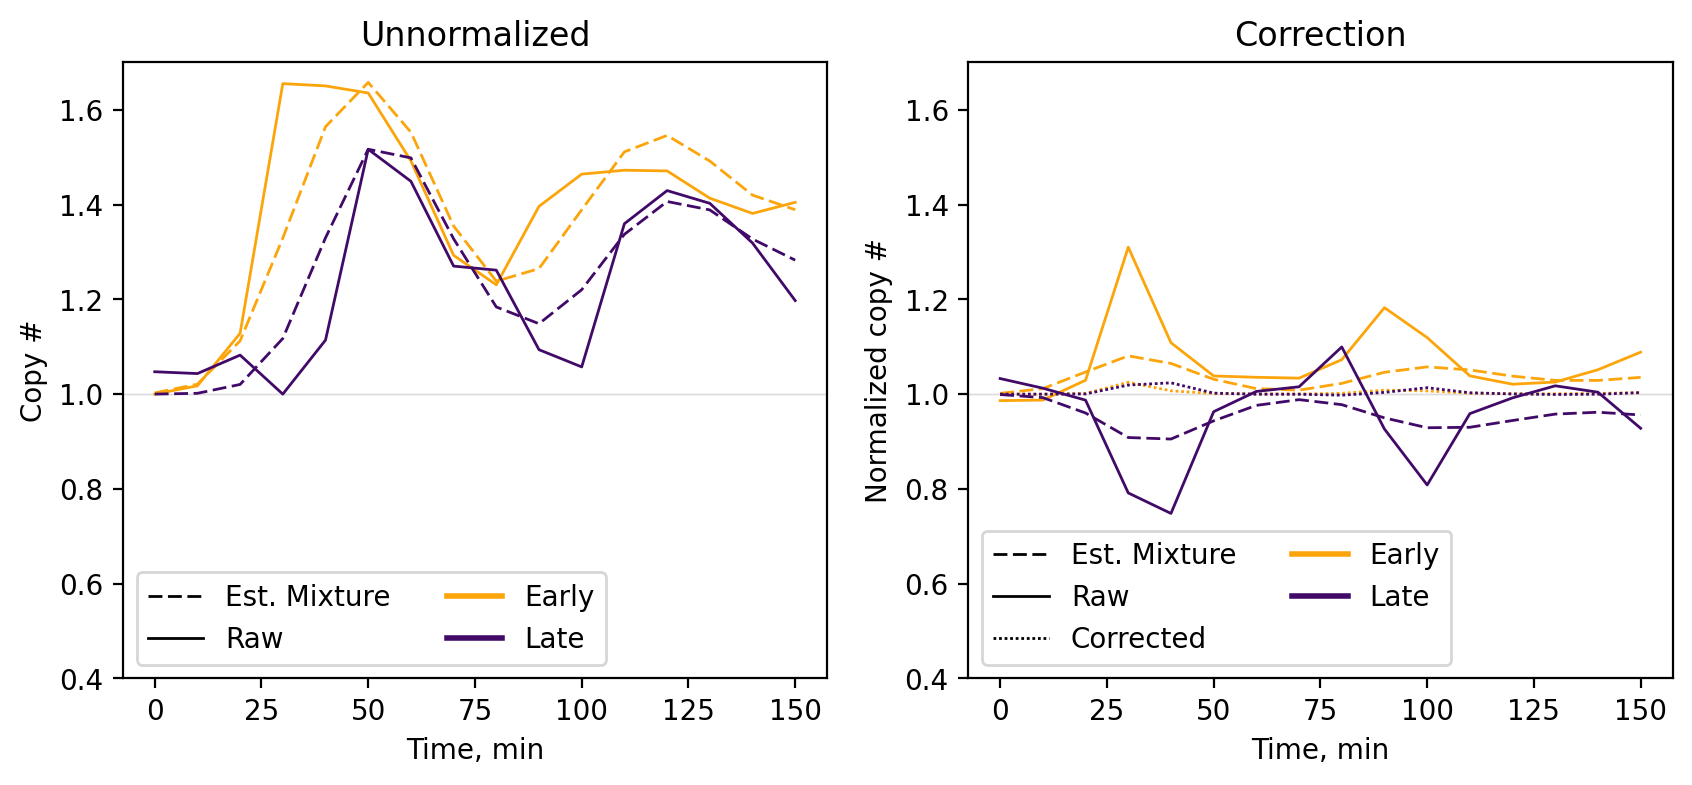

In [748]:
copy_analysis.plot_normalization_example_curves()

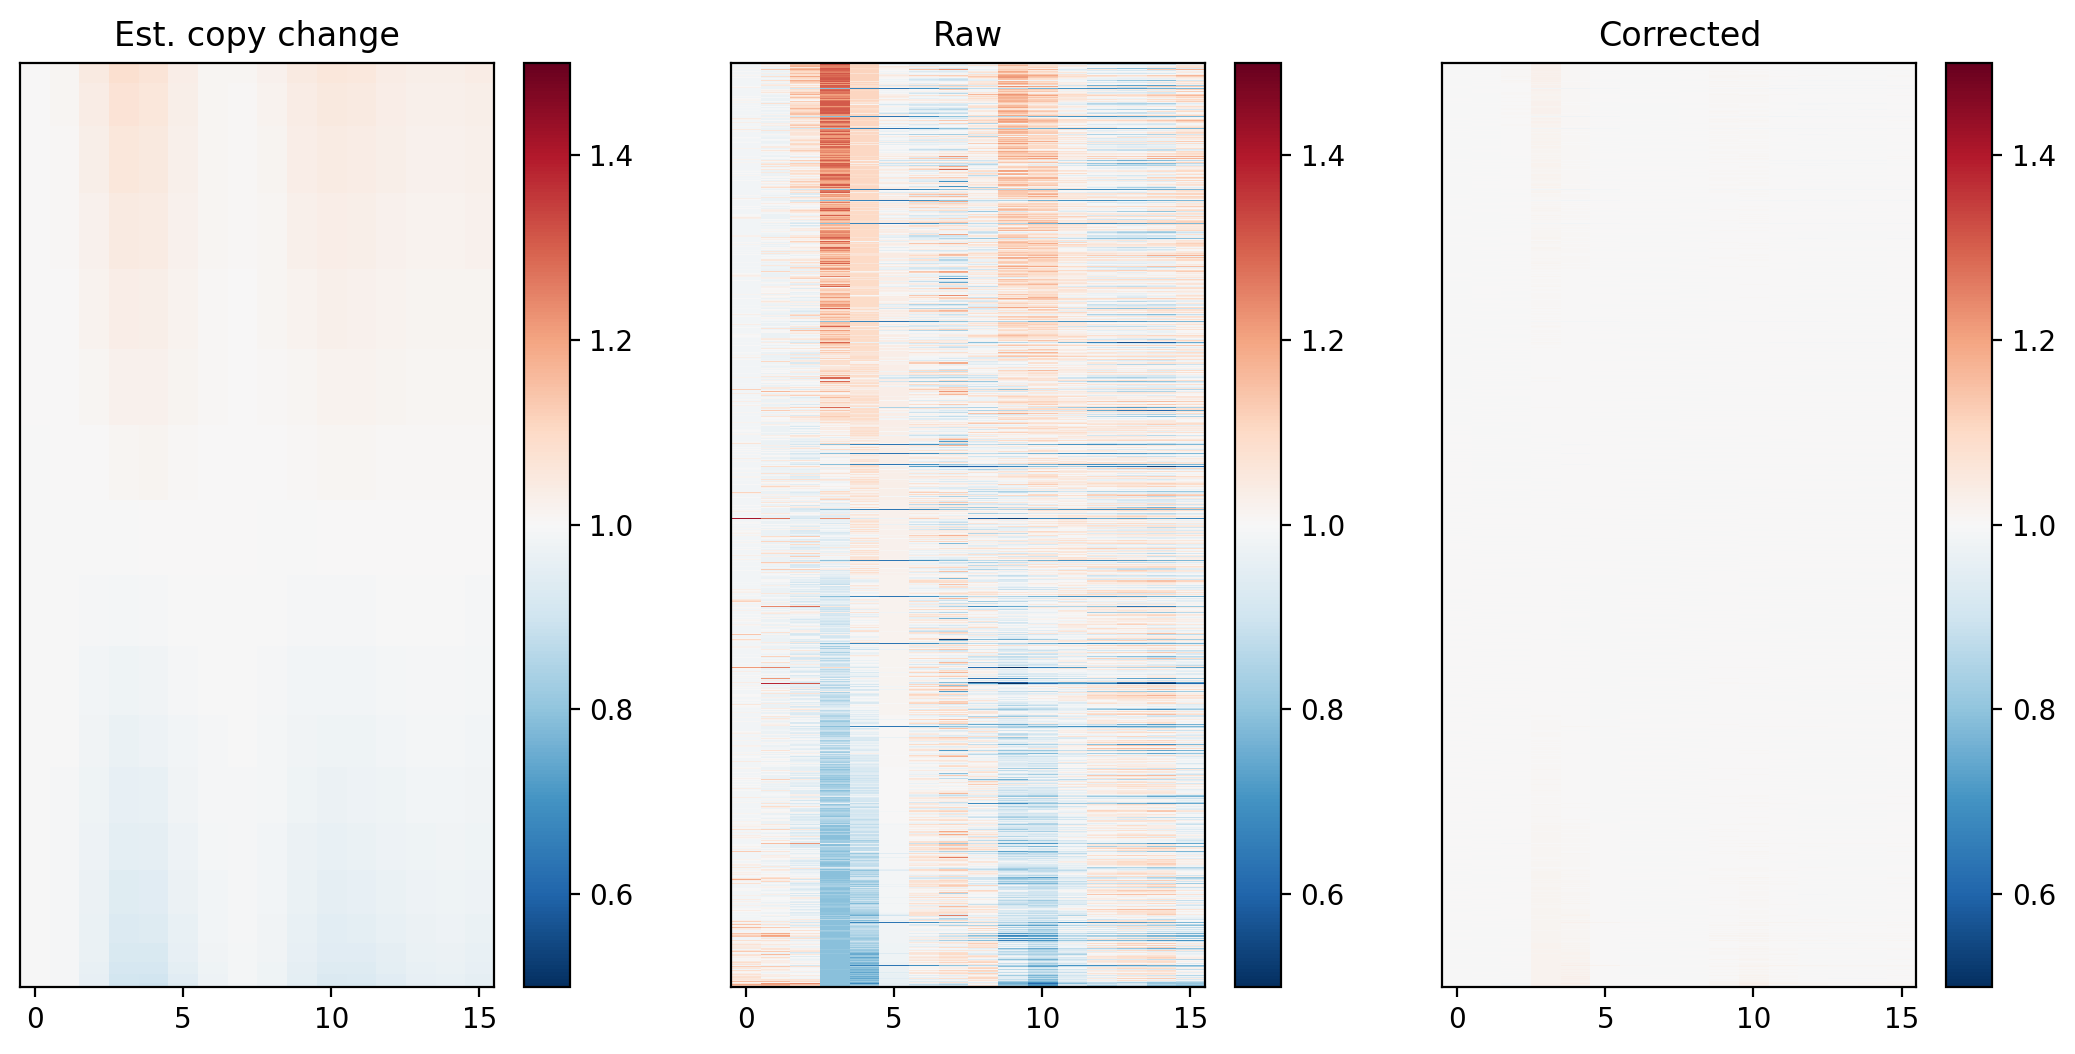

In [750]:
copy_analysis.plot_heatmap_correction()

In [752]:
copy_analysis.compute_ptr_correction()

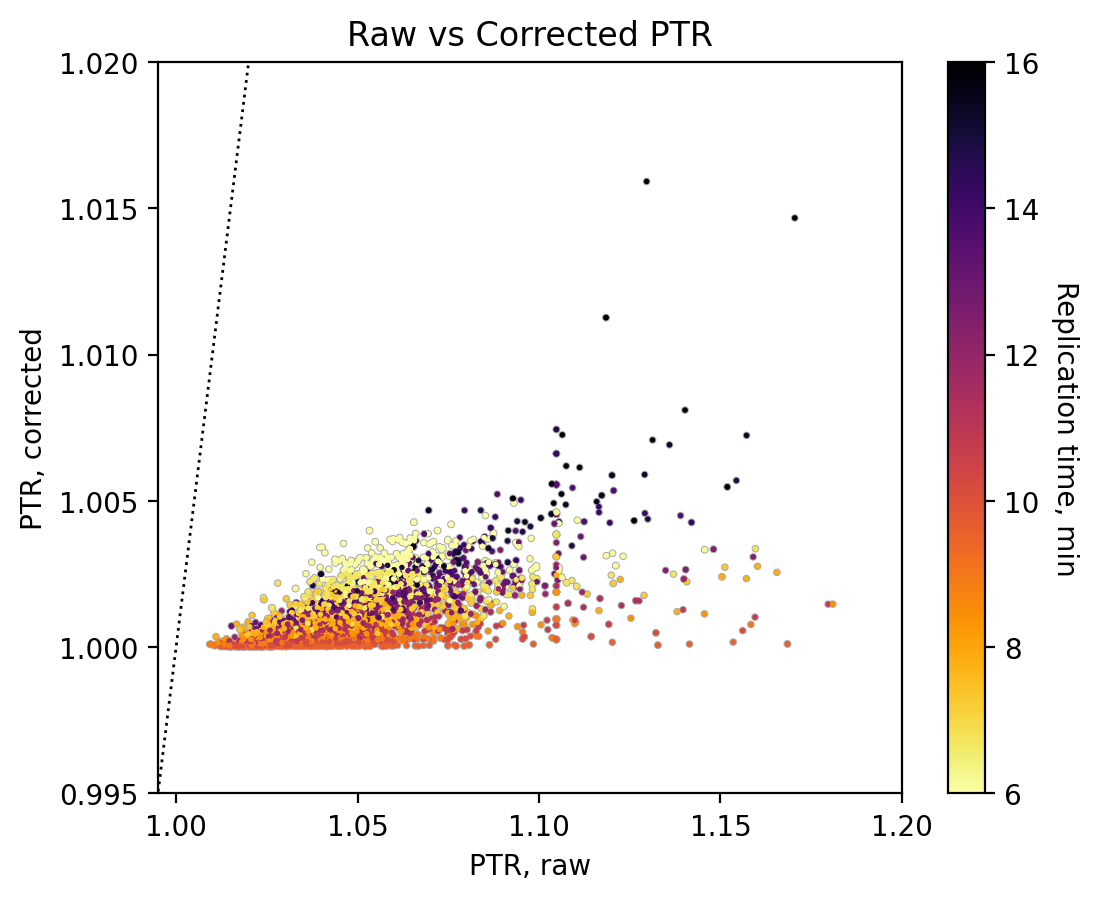

In [764]:
from src.figure_configs import save_figure_for_paper

copy_analysis.plot_ptr_scatter()
save_figure_for_paper("output/figures/Copy_Correction/10kb_Correction_PTR.png")